# Named Entity Recognition (NER) with Word Embeddings

**Goal:** teach a model to find *named entities* in English text: people (PER), organisations (ORG), locations (LOC) and other names (MISC, e.g. nationalities or events).

For example, in *"Eric Niyonzima met the president of Kenya in Nairobi."* we want: `Eric Niyonzima` = PER, `Kenya` = LOC, `Nairobi` = LOC.

**Plan:**
1. Load and explore the CoNLL-2003 dataset
2. Baseline model **without** embeddings (the "before")
3. Model **with GloVe** embeddings (the "after")
4. Model with **FastText** embeddings, and how each handles unknown words
5. Compare all three and look at mistakes
6. Test on a small set of Rwandan sentences
7. Try the best model on new sentences

The reusable code (loading data, building features, training, evaluating, predicting) lives in **`src/ner_utils.py`**, so it can be reused later with another dataset or other embeddings (for example a Kinyarwanda dataset like MasakhaNER). This notebook imports it as `nu`.

## Step 1: Load the dataset
We import the libraries we need. `datasets` downloads data from Hugging Face, and `seqeval` scores NER predictions per entity type.

In [1]:
import gc
import inspect
import os
import sys
import time
import warnings
warnings.filterwarnings("ignore")

from collections import Counter

import numpy as np
import pandas as pd
import datasets
from seqeval.metrics import classification_report
from seqeval.metrics.sequence_labeling import get_entities

sys.path.append(os.path.abspath("../src"))
import ner_utils as nu  # our reusable NER helpers

datasets.disable_progress_bars()  # keep the notebook output clean
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 80)

We load **CoNLL-2003**, the standard English NER dataset (news articles from Reuters).

The original Hugging Face version (`conll2003`) uses an old "loading script" that newer versions of `datasets` refuse to run. So we load Hugging Face's automatic **parquet copy of the same dataset** (`eriktks/conll2003`, revision `refs/convert/parquet`). It has the same sentences, the same labels and the same official train / validation / test splits.

In [2]:
splits, TAG_NAMES = nu.load_hf_ner("eriktks/conll2003", revision="refs/convert/parquet")
train_tokens, train_tags = splits["train"]
val_tokens, val_tags = splits["validation"]
test_tokens, test_tags = splits["test"]
print({split: len(tokens) for split, (tokens, _) in splits.items()}, "sentences")

{'train': 14041, 'validation': 3250, 'test': 3453} sentences


Each sentence is a list of **tokens** (words and punctuation) and a matching list of **NER tags**. `nu.load_hf_ner` has already turned the tag numbers back into their names (like `B-PER`).

In [3]:
print("Tag set:", TAG_NAMES)
for word, tag in zip(train_tokens[0], train_tags[0]):
    print(f"{word:10} {tag}")

Tag set: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
EU         B-ORG
rejects    O
German     B-MISC
call       O
to         O
boycott    O
British    B-MISC
lamb       O
.          O


### What do the tags mean? (the BIO format)
- `B-` means the **B**eginning of an entity, and `I-` means **I**nside it (the 2nd, 3rd... word of the same entity).
- `O` means **O**utside: the word is not part of any entity.

So "Eric Niyonzima" is tagged `B-PER I-PER`. There are 4 entity types: **PER** (person), **ORG** (organisation), **LOC** (location) and **MISC** (other names, like "German" or "World Cup").

**Note:** CoNLL-2003 has **no DATE type**. Words like "Friday" or "1996" are tagged `O`, so none of our models can learn to find dates.

### How big is each split?

In [4]:
rows = []
for name, toks, tags in [("train", train_tokens, train_tags),
                         ("validation", val_tokens, val_tags),
                         ("test", test_tokens, test_tags)]:
    row = {"split": name, "sentences": len(toks), "tokens": sum(len(s) for s in toks)}
    row.update(nu.count_entities(tags))  # counts the B- tags: each entity starts with exactly one
    rows.append(row)

split_summary = pd.DataFrame(rows).set_index("split")
split_summary

,sentences,tokens,PER,ORG,LOC,MISC
split,,,,,,
train,14041,203621,6600,6321,7140,3438
validation,3250,51362,1842,1341,1837,922
test,3453,46435,1617,1661,1668,702


How common is each tag? Most tokens are `O`, so the dataset is very **imbalanced**. That's why we judge models with entity-level precision, recall and F1, not plain accuracy: a model that tags everything `O` would already have high accuracy.

In [5]:
tag_counts = Counter(t for seq in train_tags for t in seq)
tag_share = pd.DataFrame({"count": pd.Series(tag_counts)}).loc[TAG_NAMES]
tag_share["percent"] = (100 * tag_share["count"] / tag_share["count"].sum()).round(2)
tag_share

,count,percent
O,169578,83.28
B-PER,6600,3.24
I-PER,4528,2.22
B-ORG,6321,3.10
I-ORG,3704,1.82
B-LOC,7140,3.51
I-LOC,1157,0.57
B-MISC,3438,1.69
I-MISC,1155,0.57


## Step 2: Baseline model WITHOUT embeddings (the "before")

The model looks at **one word at a time** and guesses its tag. To help, we describe each word with a small dictionary of **features**:

- **Who the word is:** the word in lowercase, the previous word and the next word (so the model sees a bit of context), and the word's last 3 letters (its suffix, e.g. "-ing" or "-ese").
- **Spelling features:** does it start with a capital letter? Is it ALL CAPS? Does it contain a digit or a hyphen? Is it the first word of the sentence? We check the neighbours' capitals too.

Here the model knows words only as **separate labels**: "Kigali" and "Nairobi" are just two different, unrelated features. That's the "no embeddings" setup.

Both feature functions live in `src/ner_utils.py`. We print their code here so we can see exactly what the model gets. We'll **reuse exactly these spelling features** in the embedding models later.

In [6]:
print(inspect.getsource(nu.spelling_features))
print(inspect.getsource(nu.baseline_features))
print(nu.baseline_features(["Eric", "Niyonzima", "visited", "Kigali", "."], 3))

def spelling_features(sentence, i):
    """Simple spelling (shape) features for the word at position i and its neighbours."""
    word = sentence[i]
    feats = {
        "is_title": word[:1].isupper(),        # starts with a capital letter
        "is_upper": word.isupper(),            # ALL CAPS, e.g. "WASAC"
        "is_lower": word.islower(),
        "has_digit": any(ch.isdigit() for ch in word),
        "has_hyphen": "-" in word,
        "is_punct": not any(ch.isalnum() for ch in word),
        "is_first": i == 0,                    # capitals at the start of a sentence mean less
        "is_last": i == len(sentence) - 1,
    }
    if i > 0:
        feats["prev_is_title"] = sentence[i - 1][:1].isupper()
        feats["prev_is_upper"] = sentence[i - 1].isupper()
    if i < len(sentence) - 1:
        feats["next_is_title"] = sentence[i + 1][:1].isupper()
        feats["next_is_upper"] = sentence[i + 1].isupper()
    return {name: float(value) for name, value in feats.items()}

def b

Now we turn every word in every sentence into a feature dictionary. `DictVectorizer` then converts these dictionaries into a big table of numbers (one column per possible feature). This is the same "lots of mostly-zero columns" idea as TF-IDF in my spam classifier.

In [7]:
baseline_featurizer = nu.BaselineFeaturizer()
X_train_base = baseline_featurizer.fit_transform(train_tokens)
X_val_base = baseline_featurizer.transform(val_tokens)
X_test_base = baseline_featurizer.transform(test_tokens)
y_train = nu.flatten(train_tags)

print("Training table:", X_train_base.shape[0], "words x", X_train_base.shape[1], "features")

Training table: 203621 words x 65784 features


### Training, and choosing a setting on the validation set
We use **Logistic Regression**, a simple and fast linear classifier. It has one main setting, `C`: a small `C` keeps the model simple, and a large `C` lets it fit the training data more closely.

We try the same six values of `C` for every Logistic Regression in this notebook (0.001 to 100) and keep the one with the best F1 on the **validation** set. We don't touch the test set while choosing, so the test score stays a fair "exam on unseen data".

`seqeval` scores at the **entity** level: "Eric Niyonzima" only counts as correct if *both* words get the right tags.

In [8]:
CS = [0.001, 0.01, 0.1, 1, 10, 100]
models, test_preds, results, val_scores = {}, {}, {}, {}

def record(name, model, X_val, X_test):
    """Store a trained model with its validation F1 and its full test-set report."""
    models[name] = model
    _, _, val_scores[name] = nu.evaluate(model, X_val, val_tokens, val_tags)
    test_preds[name], results[name], _ = nu.evaluate(model, X_test, test_tokens, test_tags)

baseline_model = nu.train_logreg_with_validation(X_train_base, y_train, X_val_base,
                                                 val_tokens, val_tags, Cs=CS)

C=0.001  validation F1 = 0.2964   (5s)


C=0.01   validation F1 = 0.5920   (14s)


C=0.1    validation F1 = 0.7436   (37s)


C=1      validation F1 = 0.8258   (24s)


C=10     validation F1 = 0.8376   (22s)


C=100    validation F1 = 0.8319   (22s)
Best C: 10


### Test-set results for the baseline
Now we run the chosen model **once** on the test set. For each entity type:
- **Precision:** of the entities the model found, how many were right?
- **Recall:** of the real entities, how many did the model find?
- **F1:** a single score that balances the two.

In [9]:
record("Baseline (no embeddings)", baseline_model, X_val_base, X_test_base)
nu.print_report(test_tags, test_preds["Baseline (no embeddings)"])

              precision    recall  f1-score   support

         LOC      0.801     0.815     0.808      1668
        MISC      0.730     0.775     0.752       702
         ORG      0.627     0.650     0.638      1661
         PER      0.711     0.811     0.758      1617

   micro avg      0.715     0.760     0.737      5648
   macro avg      0.717     0.763     0.739      5648
weighted avg      0.715     0.760     0.737      5648



## Step 3: NER WITH GloVe embeddings (the "after")

Now we replace "who the word is" with a **word embedding**: a list of numbers learned from huge amounts of text, where words used in similar ways get similar numbers. With embeddings, "Kigali" and "Nairobi" look *similar* to the model, so what it learns about one can help with the other.

We use the same small **GloVe** vectors as in `word_embeddings.ipynb`: 50 numbers per word, trained on Wikipedia and news.

In [10]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-50")
print("GloVe vocabulary:", len(glove), "words,", glove.vector_size, "numbers per word")
print("Similar to 'kigali':", [w for w, _ in glove.most_similar("kigali", topn=5)])

GloVe vocabulary: 400000 words, 50 numbers per word
Similar to 'kigali': ['kinshasa', 'rwanda', 'goma', 'bujumbura', 'dili']


### Building the features
For each word we put three vectors side by side: **previous word + this word + next word** (3 x 50 = 150 numbers), so the model sees some context.

- GloVe only contains **lowercase** words, so we look words up in lowercase.
- If a word isn't in GloVe (it's **out of vocabulary**, or OOV), we use a vector of zeros, which means "no information".

**Why we still add the spelling features:** lowercasing throws away capital letters, and capitals are one of the strongest clues in English NER ("Apple" the company vs "apple" the fruit). So we add back the **exact same spelling features as the baseline**. That way the only thing that changes between the two models is how the word itself is represented: a separate label (baseline) or an embedding (this model).

This is done by `nu.EmbeddingFeaturizer` (code printed below). `nu.make_lookup` turns the GloVe vectors into a "word -> vector, or None if unknown" function.

In [11]:
glove_lookup = nu.make_lookup(glove, try_original_case=False)  # GloVe is lowercase only
print(inspect.getsource(nu.EmbeddingFeaturizer))

class EmbeddingFeaturizer:
    """Dense features: [previous, current, next word vectors] + spelling features, standardised.

    Unknown words (and the slots before the first / after the last word) get a zero vector.
    """

    def __init__(self, lookup, dim, spelling_fn=spelling_features):
        self.lookup, self.dim, self.spelling_fn = lookup, dim, spelling_fn
        self.spelling_vectorizer = DictVectorizer()
        self.scaler = StandardScaler()

    def _raw(self, sentences):
        n_words = sum(len(s) for s in sentences)
        vectors = np.zeros((n_words, 3 * self.dim), dtype=np.float32)
        row = 0
        for sent in sentences:
            sent_vecs = [self.lookup(w) for w in sent]
            for i in range(len(sent)):
                for slot, j in enumerate([i - 1, i, i + 1]):          # previous, current, next
                    if 0 <= j < len(sent) and sent_vecs[j] is not None:
                        vectors[row, slot * self.dim:(slot + 1) * self.dim] = se

### How many words does GloVe not know?
We count out-of-vocabulary (OOV) words in each split, both as a share of all tokens and as a share of distinct words.

In [12]:
def oov_report(lookup, name):
    print(name)
    return pd.DataFrame({split: nu.oov_stats(toks, lookup)
                         for split, toks in [("train", train_tokens), ("validation", val_tokens),
                                             ("test", test_tokens)]}).T

oov_report(glove_lookup, "GloVe out-of-vocabulary words")

GloVe out-of-vocabulary words


,OOV tokens,OOV % of tokens,OOV distinct words,OOV % of distinct words,examples
train,4632,2.27,2614,11.07,"**General, *INDICES, *Name, *Note, ++359-2, +0,2, +0.0, +0.05"
validation,1054,2.05,673,6.75,"+0.089, +0.237, +0.300, +0.435, +0.578, +1.660, +10.436, +27-11"
test,1331,2.87,842,8.87,"*1995, *from, +$0.50, +212-859-1628, +371, +392, +44-171-542, +48"


Now we build the tables. The featurizer also **standardises** each column (shift and scale it so it has mean 0 and spread 1). Then the GloVe numbers and the 0/1 spelling features are on the same scale, which helps Logistic Regression train well.

In [13]:
glove_featurizer = nu.EmbeddingFeaturizer(glove_lookup, glove.vector_size)
X_train_glove = glove_featurizer.fit_transform(train_tokens)
X_val_glove = glove_featurizer.transform(val_tokens)
X_test_glove = glove_featurizer.transform(test_tokens)
print("Training table:", X_train_glove.shape[0], "words x", X_train_glove.shape[1], "features")
print(f"(baseline had {X_train_base.shape[1]} mostly-zero columns; this one has {X_train_glove.shape[1]} dense columns)")

Training table: 203621 words x 162 features
(baseline had 65784 mostly-zero columns; this one has 162 dense columns)


### Training: same classifier, C chosen on validation
Exactly the same procedure as the baseline: Logistic Regression, try several values of `C`, and keep the best on the validation set.

In [14]:
glove_logreg = nu.train_logreg_with_validation(X_train_glove, y_train, X_val_glove,
                                               val_tokens, val_tags, Cs=CS)

C=0.001  validation F1 = 0.7653   (10s)


C=0.01   validation F1 = 0.7757   (18s)


C=0.1    validation F1 = 0.7759   (18s)


C=1      validation F1 = 0.7743   (30s)


C=10     validation F1 = 0.7725   (38s)


C=100    validation F1 = 0.7767   (28s)
Best C: 100


### Test-set results for GloVe
We evaluate **once** on the test set with the same seqeval report.

In [15]:
record("GloVe + LogReg", glove_logreg, X_val_glove, X_test_glove)
nu.print_report(test_tags, test_preds["GloVe + LogReg"])

              precision    recall  f1-score   support

         LOC      0.752     0.836     0.792      1668
        MISC      0.577     0.687     0.627       702
         ORG      0.611     0.647     0.628      1661
         PER      0.863     0.885     0.874      1617

   micro avg      0.718     0.776     0.746      5648
   macro avg      0.701     0.763     0.730      5648
weighted avg      0.721     0.776     0.747      5648



### Two more classifiers on the same GloVe features
Logistic Regression draws **straight lines** between the tags. With embeddings, the useful patterns may be curvier: for example, "a capitalised word whose vector sits near city names, right after 'in'". So we also try two models that can learn curved, non-linear patterns. All three get exactly the same GloVe features.

- **Random Forest:** many decision trees, each asking yes/no questions like "is number 17 of the vector above 0.3?", and the trees vote. It can combine features in non-linear ways and needs no scaling. Settings: 100 trees, at least 5 words per leaf (to keep memory use down on 200k words), `n_jobs=-1` to use every CPU core.
- **MLP (small neural network):** one hidden layer of 256 "neurons" that learns its own combinations of the embedding numbers before choosing a tag. Neural networks are the usual partner for dense embeddings. `early_stopping=True` holds back 10% of the training words and stops training when the score on them stops improving, which saves time and avoids overfitting.

We didn't tune these settings: we picked reasonable defaults once, for both GloVe and FastText. Only Logistic Regression's `C` was tuned. All three models are trained on the **full** training set.

In [16]:
print(inspect.getsource(nu.make_random_forest))
print(inspect.getsource(nu.make_mlp))

def fit_and_report(name, model, X_train, X_val, X_test):
    """Train on the full training set, then print validation F1 and the test-set seqeval report."""
    start = time.time()
    model.fit(X_train, y_train)
    record(name, model, X_val, X_test)
    print(f"{name}: validation F1 = {val_scores[name]:.4f}   ({time.time() - start:.0f}s)\n")
    nu.print_report(test_tags, test_preds[name])

def make_random_forest():
    return RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=42)

def make_mlp():
    return MLPClassifier(hidden_layer_sizes=(256,), early_stopping=True, max_iter=50, random_state=42)



**Random Forest with GloVe features:**

In [17]:
fit_and_report("GloVe + RandomForest", nu.make_random_forest(), X_train_glove, X_val_glove, X_test_glove)

GloVe + RandomForest: validation F1 = 0.8680   (87s)



              precision    recall  f1-score   support

         LOC      0.846     0.887     0.866      1668
        MISC      0.776     0.704     0.738       702
         ORG      0.713     0.764     0.738      1661
         PER      0.829     0.907     0.866      1617

   micro avg      0.793     0.834     0.813      5648
   macro avg      0.791     0.815     0.802      5648
weighted avg      0.793     0.834     0.812      5648



**MLP (neural network) with GloVe features:**

In [18]:
fit_and_report("GloVe + MLP", nu.make_mlp(), X_train_glove, X_val_glove, X_test_glove)
print("MLP stopped after", models["GloVe + MLP"].n_iter_, "passes over the training data")

GloVe + MLP: validation F1 = 0.8668   (79s)



              precision    recall  f1-score   support

         LOC      0.810     0.905     0.855      1668
        MISC      0.654     0.731     0.690       702
         ORG      0.698     0.769     0.732      1661
         PER      0.875     0.892     0.883      1617

   micro avg      0.774     0.840     0.806      5648
   macro avg      0.759     0.824     0.790      5648
weighted avg      0.776     0.840     0.806      5648

MLP stopped after 27 passes over the training data


## Step 4: GloVe vs FastText

**FastText** (from Facebook) learns vectors for **pieces of words** (character n-grams like `<ki`, `kic`, `icu`, ...) as well as whole words. A word's vector is built from its pieces, so in principle FastText can make a vector even for a word it **never saw**, like *Kicukiro*, by adding up the vectors of its pieces.

We load the pre-trained `fasttext-wiki-news-subwords-300` vectors through gensim: 1 million words, 300 numbers each, trained on Wikipedia and news. **It's a ~1 GB download**, so the first run takes a while.

**Important catch:** this gensim download contains only the finished **whole-word** vectors, not the table of word-piece vectors. So in practice it behaves like a big lookup table: words that aren't in its 1 million entries get **nothing**, just like GloVe. The full model with the word-piece table is a 4.5 GB download (about 7 GB unzipped) and needs more memory than this laptop has free. We'll still show how word pieces work, using a small FastText model we train ourselves (below).

To save memory, we load the vectors once, save them in gensim's own format in `data/embeddings/` (ignored by git, so they're never committed), and then open that file **memory-mapped**: the vectors stay on disk and are only read when needed.

In [19]:
from gensim.models import KeyedVectors

FASTTEXT_PATH = "../data/embeddings/fasttext-wiki-news-subwords-300.kv"
if not os.path.exists(FASTTEXT_PATH):
    os.makedirs(os.path.dirname(FASTTEXT_PATH), exist_ok=True)
    api.load("fasttext-wiki-news-subwords-300").save(FASTTEXT_PATH)  # ~1 GB download, first run only
    gc.collect()
fasttext = KeyedVectors.load(FASTTEXT_PATH, mmap="r")
print("FastText vocabulary:", len(fasttext), "words,", fasttext.vector_size, "numbers per word")
print("Has the word-piece table?", hasattr(fasttext, "vectors_ngrams"))

FastText vocabulary: 999999 words, 300 numbers per word
Has the word-piece table? False


### Looking words up in FastText
Unlike GloVe, these FastText vectors are **case-sensitive** ("Apple" and "apple" are different entries). So we try the word exactly as written first, then fall back to lowercase.

In [20]:
fasttext_lookup = nu.make_lookup(fasttext, try_original_case=True)  # as written first, then lowercase
oov_report(fasttext_lookup, "FastText out-of-vocabulary words")

FastText out-of-vocabulary words


,OOV tokens,OOV % of tokens,OOV distinct words,OOV % of distinct words,examples
train,4661,2.29,2584,10.94,"**, **General, *INDICES, *Name, *Note, ++359-2, +0,2, +0.0"
validation,1070,2.08,699,7.01,"+0.089, +0.237, +0.300, +0.435, +0.578, +1, +1.660, +10.436"
test,1345,2.9,858,9.04,"*1995, *from, +$0.50, +1, +212-859-1628, +31, +32, +371"


### How do the two embeddings handle unknown words?
We check some Rwandan place names, organisations and people, plus a couple of well-known words for comparison. `True` means the embedding has a vector for the word.

In [21]:
probe_words = ["Kigali", "Nairobi", "Kicukiro", "Gikondo", "Nyarugenge", "Kimironko", "Remera",
               "Musanze", "Huye", "WASAC", "REG", "Niyonzima", "Rwanda"]
probe = pd.DataFrame({
    "in GloVe (lowercased)": [w.lower() in glove for w in probe_words],
    "in FastText (as written or lowercased)": [fasttext_lookup(w) is not None for w in probe_words],
}, index=probe_words)
probe

,in GloVe (lowercased),in FastText (as written or lowercased)
Kigali,True,True
Nairobi,True,True
Kicukiro,False,True
Gikondo,False,True
Nyarugenge,False,True
Kimironko,False,False
Remera,False,False
Musanze,False,True
Huye,True,True
WASAC,False,False


**What the table shows:** FastText's vocabulary is 2.5 times bigger than GloVe's (1 million words vs 400,000) and it was trained on more web text, so it **does** know several Rwandan places as whole words: Kicukiro, Gikondo, Nyarugenge and Musanze. GloVe knows none of these. Both miss Kimironko, Remera and WASAC, and because this FastText file has no word-piece table, those words get a zero vector in both models.

What are the nearest neighbours of these words? Sensible neighbours suggest the embedding has learned something real about the word.

In [22]:
for word in ["Kigali", "Kicukiro", "Gikondo"]:
    g = [w for w, _ in glove.most_similar(word.lower(), topn=5)] if word.lower() in glove else "not in GloVe"
    form = next((f for f in (word, word.lower()) if f in fasttext.key_to_index), None)
    f = [w for w, _ in fasttext.most_similar(form, topn=5)] if form else "not in FastText"
    print(f"{word}\n  GloVe:    {g}\n  FastText: {f}")

Kigali
  GloVe:    ['kinshasa', 'rwanda', 'goma', 'bujumbura', 'dili']
  FastText: ['Rwanda', 'Bujumbura', 'Kampala', 'Kinshasa', 'Bukavu']
Kicukiro
  GloVe:    not in GloVe
  FastText: ['Epukiro', 'Brikama', 'Muliro', 'Nyarugenge', 'Hoima']
Gikondo
  GloVe:    not in GloVe
  FastText: ['Matondo', 'Dondo', 'Jondo', 'Mulondo', 'Sismondo']


### Seeing word pieces (subwords) in action
To show *how* FastText builds vectors for unseen words, we train a **small FastText model with word pieces** on the CoNLL training sentences (it's only for this demo, not for the NER models). Every word is broken into pieces of 3 to 6 characters, with `<` and `>` marking the start and end of the word.

In [23]:
from gensim.models import FastText

small_ft = FastText(sentences=train_tokens, vector_size=50, window=5, min_count=2,
                    min_n=3, max_n=6, epochs=10, seed=42, workers=4)

def pieces(word, min_n=3, max_n=6):
    w = f"<{word}>"
    return [w[i:i + n] for n in range(min_n, max_n + 1) for i in range(len(w) - n + 1)]

print("Pieces of 'Kicukiro' (first 12):", pieces("Kicukiro")[:12], "...")
for word in ["Kicukiro", "Gikondo"]:
    print(f"\n{word}: in the small model's vocabulary? {word in small_ft.wv.key_to_index}")
    print("  ...but it still gets a vector built from its pieces. Vector starts:", np.round(small_ft.wv[word][:4], 3))
    print("  Nearest known words:", [w for w, _ in small_ft.wv.most_similar(word, topn=5)])

Pieces of 'Kicukiro' (first 12): ['<Ki', 'Kic', 'icu', 'cuk', 'uki', 'kir', 'iro', 'ro>', '<Kic', 'Kicu', 'icuk', 'cuki'] ...

Kicukiro: in the small model's vocabulary? False
  ...but it still gets a vector built from its pieces. Vector starts: [ 0.1    0.065 -0.115 -0.008]
  Nearest known words: ['Fitzroy', 'Lietti', 'AC', 'Sochi', 'Vladikavkaz']

Gikondo: in the small model's vocabulary? False
  ...but it still gets a vector built from its pieces. Vector starts: [ 0.136  0.075 -0.21  -0.071]
  Nearest known words: ['Belmondo', 'Machnee', 'Mitchell', 'Coulthard', 'Wells']


The small model has never seen "Kicukiro" or "Gikondo", but it can still build vectors for them from their pieces, while GloVe can only say "not found". The neighbours show the limits, though: look at the lists above. They are words that happen to **share some spelling pieces**, or just other rare names, and **none of them are Rwandan places**. (Training this small model involves randomness, so the exact neighbours can change each time the notebook runs.) The model was trained on only 14,000 sentences, which is far too little text to give the pieces real meaning. Compare the big FastText model above, which put Kicukiro next to Nyarugenge, another district of Kigali, because it learned Kicukiro as a whole word from a huge amount of text. That's why subword models are promising for my capstone (Kinyarwanda words share many prefixes and suffixes).

### Training the same three models on FastText features
Same recipe as GloVe: previous + current + next word vectors (3 x 300 = 900 numbers), plus the same spelling features, then standardised.

In [24]:
# Free the GloVe training table first to save memory (the trained GloVe models are kept)
del X_train_glove
gc.collect()

fasttext_featurizer = nu.EmbeddingFeaturizer(fasttext_lookup, fasttext.vector_size)
X_train_ft = fasttext_featurizer.fit_transform(train_tokens)
X_val_ft = fasttext_featurizer.transform(val_tokens)
X_test_ft = fasttext_featurizer.transform(test_tokens)
print("Training table:", X_train_ft.shape[0], "words x", X_train_ft.shape[1], "features,", X_train_ft.dtype)

Training table: 203621 words x 912 features, float32


**Logistic Regression with FastText features** (C chosen on validation, as before).

In [25]:
fasttext_logreg = nu.train_logreg_with_validation(X_train_ft, y_train, X_val_ft, val_tokens, val_tags, Cs=CS)
record("FastText + LogReg", fasttext_logreg, X_val_ft, X_test_ft)
nu.print_report(test_tags, test_preds["FastText + LogReg"])

C=0.001  validation F1 = 0.8514   (17s)


C=0.01   validation F1 = 0.8631   (13s)


C=0.1    validation F1 = 0.8493   (16s)


C=1      validation F1 = 0.8410   (23s)


C=10     validation F1 = 0.8360   (22s)


C=100    validation F1 = 0.8337   (50s)
Best C: 0.01


              precision    recall  f1-score   support

         LOC      0.822     0.885     0.853      1668
        MISC      0.674     0.754     0.711       702
         ORG      0.697     0.759     0.727      1661
         PER      0.897     0.912     0.904      1617

   micro avg      0.786     0.839     0.812      5648
   macro avg      0.772     0.827     0.799      5648
weighted avg      0.788     0.839     0.813      5648



**Random Forest with FastText features:**

In [26]:
fit_and_report("FastText + RandomForest", nu.make_random_forest(), X_train_ft, X_val_ft, X_test_ft)

FastText + RandomForest: validation F1 = 0.8594   (197s)



              precision    recall  f1-score   support

         LOC      0.844     0.865     0.854      1668
        MISC      0.751     0.695     0.722       702
         ORG      0.705     0.732     0.718      1661
         PER      0.861     0.892     0.877      1617

   micro avg      0.797     0.812     0.805      5648
   macro avg      0.790     0.796     0.793      5648
weighted avg      0.796     0.812     0.804      5648



**MLP (neural network) with FastText features:**

In [27]:
fit_and_report("FastText + MLP", nu.make_mlp(), X_train_ft, X_val_ft, X_test_ft)
print("MLP stopped after", models["FastText + MLP"].n_iter_, "passes over the training data")

FastText + MLP: validation F1 = 0.8726   (375s)



              precision    recall  f1-score   support

         LOC      0.821     0.895     0.856      1668
        MISC      0.709     0.751     0.729       702
         ORG      0.713     0.791     0.750      1661
         PER      0.867     0.919     0.892      1617

   micro avg      0.788     0.853     0.819      5648
   macro avg      0.777     0.839     0.807      5648
weighted avg      0.788     0.853     0.819      5648

MLP stopped after 34 passes over the training data


## Step 5: Compare and analyse

### Comparison table
One row per model. The four entity columns and "overall" are **test-set F1** scores. "Overall" is the micro-average, which counts every entity equally. The last column is the overall F1 on the **validation** set.

We pick the best model by **overall validation F1**. Picking on the test set would turn our final exam into practice questions, and its score would look better than it really is. The test F1 column shows how each choice held up on unseen data.

In [28]:
ENTITY_TYPES = nu.ENTITY_TYPES

def family(name):
    return "Baseline" if name.startswith("Baseline") else name.split(" + ")[0]

comparison = pd.DataFrame({
    name: {**{etype: report[etype]["f1-score"] for etype in ENTITY_TYPES},
           "overall F1 (test)": report["micro avg"]["f1-score"],
           "overall F1 (validation)": val_scores[name]}
    for name, report in results.items()
}).T.round(3)
comparison

,PER,ORG,LOC,MISC,overall F1 (test),overall F1 (validation)
Baseline (no embeddings),0.758,0.638,0.808,0.752,0.737,0.838
GloVe + LogReg,0.874,0.628,0.792,0.627,0.746,0.777
GloVe + RandomForest,0.866,0.738,0.866,0.738,0.813,0.868
GloVe + MLP,0.883,0.732,0.855,0.690,0.806,0.867
FastText + LogReg,0.904,0.727,0.853,0.711,0.812,0.863
FastText + RandomForest,0.877,0.718,0.854,0.722,0.805,0.859
FastText + MLP,0.892,0.750,0.856,0.729,0.819,0.873


Precision and recall per entity type for every model (test set):

In [29]:
detail = pd.DataFrame({
    (name, etype): {"precision": results[name][etype]["precision"],
                    "recall": results[name][etype]["recall"],
                    "f1": results[name][etype]["f1-score"]}
    for name in results for etype in ENTITY_TYPES + ["micro avg"]
}).T.round(3)
detail.unstack(level=1).swaplevel(axis=1).sort_index(axis=1, level=0)[["PER", "ORG", "LOC", "MISC", "micro avg"]].loc[list(results)]

PER                     ORG                     LOC                    MISC                  micro avg                 
                             f1 precision recall     f1 precision recall     f1 precision recall     f1 precision recall        f1 precision recall
Baseline (no embeddings)  0.758     0.711  0.811  0.638     0.627  0.650  0.808     0.801  0.815  0.752     0.730  0.775     0.737     0.715  0.760
GloVe + LogReg            0.874     0.863  0.885  0.628     0.611  0.647  0.792     0.752  0.836  0.627     0.577  0.687     0.746     0.718  0.776
GloVe + RandomForest      0.866     0.829  0.907  0.738     0.713  0.764  0.866     0.846  0.887  0.738     0.776  0.704     0.813     0.793  0.834
GloVe + MLP               0.883     0.875  0.892  0.732     0.698  0.769  0.855     0.810  0.905  0.690     0.654  0.731     0.806     0.774  0.840
FastText + LogReg         0.904     0.897  0.912  0.727     0.697  0.759  0.853     0.822  0.885  0.711     0.674  0.754     0.812     0.786  0.839
FastText + RandomForest   0.877     0.861  0.892  0.718     0.705  0.732  0.854     0.844  0.865  0.722     0.751  0.695     0.805     0.797  0.812
FastText + MLP            0.892     0.867  0.919  0.750     0.713  0.791  0.856     0.821  0.895  0.729     0.709  0.751     0.819     0.788  0.853

### Choosing the best models

In [30]:
best_overall = comparison["overall F1 (validation)"].idxmax()
best_glove = comparison.loc[[n for n in comparison.index if family(n) == "GloVe"], "overall F1 (validation)"].idxmax()
best_fasttext = comparison.loc[[n for n in comparison.index if family(n) == "FastText"], "overall F1 (validation)"].idxmax()
best_by_test = comparison["overall F1 (test)"].idxmax()

print("Best model overall (by validation F1):", best_overall)
print("Best GloVe model:                     ", best_glove)
print("Best FastText model:                  ", best_fasttext)
print("Best model if we had looked at test F1:", best_by_test)

Best model overall (by validation F1): FastText + MLP
Best GloVe model:                      GloVe + RandomForest
Best FastText model:                   FastText + MLP
Best model if we had looked at test F1: FastText + MLP


### Chart: F1 per entity type for every model
One small panel per entity type, so each set of bars is easy to compare. The colour shows the embedding family: gray = baseline, blue = GloVe, orange = FastText.

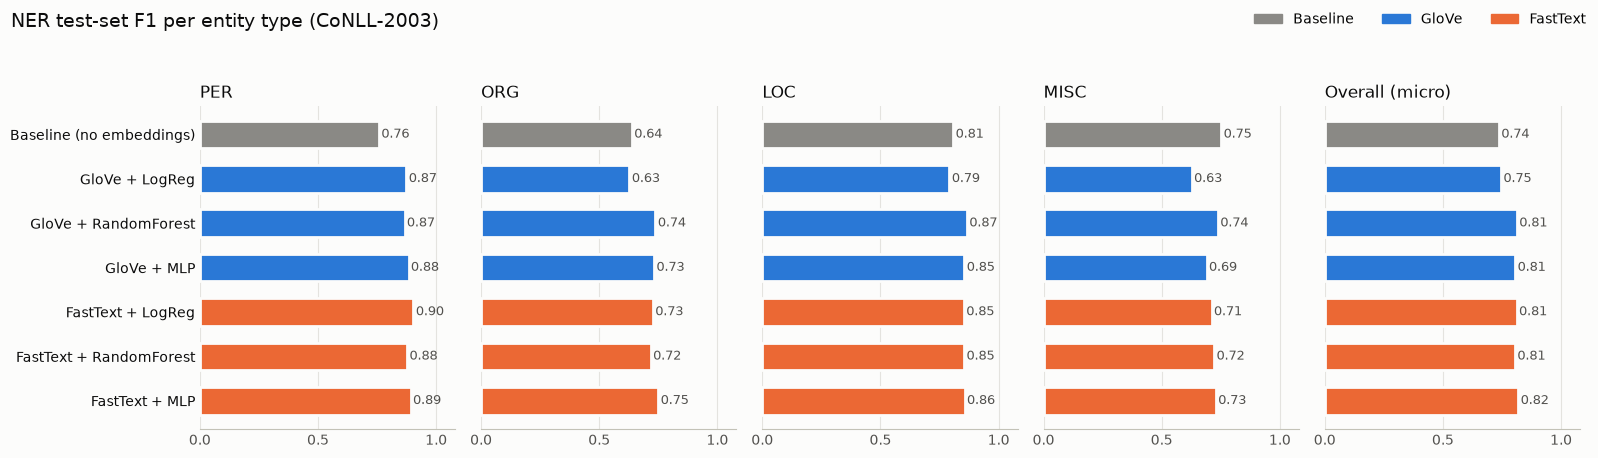

In [31]:
import matplotlib.pyplot as plt

COLORS = {"Baseline": "#8a8985", "GloVe": "#2a78d6", "FastText": "#eb6834"}
panels = ENTITY_TYPES + ["overall F1 (test)"]
order = list(comparison.index)

fig, axes = plt.subplots(1, len(panels), figsize=(16, 4.6), sharey=True)
fig.patch.set_facecolor("#fcfcfb")
for ax, col in zip(axes, panels):
    ax.set_facecolor("#fcfcfb")
    values = comparison.loc[order, col]
    ax.barh(range(len(order)), values, height=0.62, color=[COLORS[family(n)] for n in order],
            edgecolor="#fcfcfb", linewidth=2)
    for y, v in enumerate(values):
        ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=9, color="#52514e")
    ax.set_title("Overall (micro)" if col.startswith("overall") else col, fontsize=12, color="#0b0b0b", loc="left")
    ax.set_xlim(0, 1.08)
    ax.set_xticks([0, 0.5, 1])
    ax.grid(axis="x", color="#e4e3df", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors="#52514e", length=0)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(order, fontsize=10, color="#0b0b0b")
axes[0].invert_yaxis()
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORS.values()]
fig.legend(handles, COLORS.keys(), loc="upper right", ncol=3, frameon=False, fontsize=10)
fig.suptitle("NER test-set F1 per entity type (CoNLL-2003)", x=0.01, ha="left", fontsize=14, color="#0b0b0b")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig("../reports/ner_f1_comparison.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### Example sentences: right and wrong
We print a few test sentences tagged by the best model. ✔ means the predicted tag matches the true tag, and ✘ marks a mistake.

In [32]:
def show_sentence(i, pred_tags):
    print(" ".join(test_tokens[i]))
    for word, true, pred in zip(test_tokens[i], test_tags[i], pred_tags[i]):
        if true != "O" or pred != "O":
            print(f"   {word:15} true={true:7} predicted={pred:7} {'✔' if true == pred else '✘'}")
    print()

best_pred = test_preds[best_overall]
has_entities, seen_text = [], set()
for i in range(len(test_tokens)):
    text = " ".join(test_tokens[i])
    if len(get_entities(test_tags[i])) >= 2 and len(test_tokens[i]) <= 20 and text not in seen_text:
        has_entities.append(i)  # skip repeated sentences (CoNLL repeats some datelines)
        seen_text.add(text)
correct = [i for i in has_entities if best_pred[i] == test_tags[i]][:3]
wrong = [i for i in has_entities if best_pred[i] != test_tags[i]][:4]

print(f"=== Tagged correctly by {best_overall} ===\n")
for i in correct: show_sentence(i, best_pred)
print(f"=== Mistakes by {best_overall} ===\n")
for i in wrong: show_sentence(i, best_pred)

=== Tagged correctly by FastText + MLP ===

The former Soviet republic was playing in an Asian Cup finals tie for the first time .
   Soviet          true=B-MISC  predicted=B-MISC  ✔
   Asian           true=B-MISC  predicted=B-MISC  ✔
   Cup             true=I-MISC  predicted=I-MISC  ✔

Despite winning the Asian Games title two years ago , Uzbekistan are in the finals as outsiders .
   Asian           true=B-MISC  predicted=B-MISC  ✔
   Games           true=I-MISC  predicted=I-MISC  ✔
   Uzbekistan      true=B-LOC   predicted=B-LOC   ✔

Nader Jokhadar had given Syria the lead with a well-struck header in the seventh minute .
   Nader           true=B-PER   predicted=B-PER   ✔
   Jokhadar        true=I-PER   predicted=I-PER   ✔
   Syria           true=B-LOC   predicted=B-LOC   ✔

=== Mistakes by FastText + MLP ===

SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
   JAPAN           true=B-LOC   predicted=B-LOC   ✔
   LUCKY           true=O       predicted=B-ORG   ✘
   CHINA    

**Why do these mistakes happen?**
- **ALL-CAPS headlines** ("SOCCER - JAPAN GET LUCKY WIN, CHINA IN SURPRISE DEFEAT"): every word is capitalised, so the capital-letter clues stop working, and the model tags ordinary words like "LUCKY" and "SURPRISE" as entities.
- **One word, several roles:** "Japan" or "Syria" in a sports headline really means the national *team*. CoNLL labels them as LOC here, but they look like a team (ORG) to the model. Places and organisations are often the same names (e.g. "Rwanda" in "Rwanda beat Kenya"), and the table below shows that **ORG vs LOC confusion is the most common mistake** between two entity types.
- **The first word of a multi-word name:** in "United Arab Emirates", the model got "Arab Emirates" right but tagged "United" as ORG, because "United" usually starts names like "United Nations" or "Manchester United".
- **Label noise:** CoNLL itself has some wrong labels. "CHINA" is tagged as a person (PER) in this headline, which looks like an annotation error. A model can be "wrong" against a wrong label.
- **Our model looks at only one word on each side.** It can't see longer context like "...beat X 2-1", which would tell it X is a team.

### Which mistakes are most common?
We compare the true entity type and the predicted type, word by word, for the words where they differ. "O" means "not an entity".

In [33]:
def entity_type(tag):
    return tag[2:] if tag != "O" else "O"

pairs = [(entity_type(t), entity_type(p))
         for ts, ps in zip(test_tags, best_pred) for t, p in zip(ts, ps) if entity_type(t) != entity_type(p)]
confusions = pd.Series(Counter(pairs)).sort_values(ascending=False).head(8)
confusions.index = [f"true {t} -> predicted {p}" for t, p in confusions.index]
print(f"Most common word-level mistakes ({best_overall}):")
confusions

Most common word-level mistakes (FastText + MLP):


true O -> predicted ORG       159
true ORG -> predicted LOC     158
true LOC -> predicted ORG     115
true O -> predicted MISC      107
true ORG -> predicted O        97
true MISC -> predicted O       75
true MISC -> predicted ORG     74
true ORG -> predicted PER      71
dtype: int64

### Do embeddings help with words never seen in training?
This is the key promise of embeddings. We split the **test entities** into two groups:
- **seen:** at least one of the entity's words appears somewhere in the training data
- **unseen:** none of its words appear in training (e.g. a brand-new surname)

Then we measure **recall** in each group: the share of entities the model found with exactly the right words and type.

In [34]:
train_vocab = {w.lower() for s in train_tokens for w in s}

rows = {}
for name, pred in test_preds.items():
    found = nu.entity_recall_by_seen(test_tokens, test_tags, pred, train_vocab)
    rows[name] = {"recall on seen entities": found["seen"][0] / found["seen"][1],
                  "recall on unseen entities": found["unseen"][0] / found["unseen"][1]}
print(f"Test entities: {found['seen'][1]} seen, {found['unseen'][1]} unseen")
seen_unseen = pd.DataFrame(rows).T.round(3)
seen_unseen

Test entities: 4423 seen, 1225 unseen


,recall on seen entities,recall on unseen entities
Baseline (no embeddings),0.806,0.596
GloVe + LogReg,0.776,0.774
GloVe + RandomForest,0.848,0.784
GloVe + MLP,0.848,0.812
FastText + LogReg,0.852,0.793
FastText + RandomForest,0.840,0.712
FastText + MLP,0.862,0.821


**This is the key benefit of embeddings.** For entities whose words appeared in training, the baseline does reasonably well (0.806 recall). For entities with **no word seen in training**, the baseline's recall drops to **0.596**. To the baseline, an unseen word is just a column it never learned anything about, so it can only rely on capital letters and neighbours.

The embedding models keep much more of their performance on unseen entities: the best ones reach **0.812** (GloVe + MLP) and **0.821** (FastText + MLP). Embeddings were trained on billions of words of Wikipedia and news, so a surname the NER model never saw during training still lands *near other surnames* in the embedding space, and the model can use that.

### Honest discussion: what improved, what didn't, and why

**What improved**
- **Overall F1:** the baseline scores 0.737 on the test set. The best GloVe model (Random Forest) scores 0.813, and the best model overall (FastText + MLP) scores 0.819.
- **People (PER)** improved the most: from 0.758 to 0.892 with FastText + MLP. Names are the classic case of rare words: there are endless different surnames, and embeddings place them close together.
- **Unseen entities:** recall rose from 0.596 to 0.821 (see the table above).

**What didn't improve, or got worse**
- **MISC:** the baseline (0.752) is actually **better than every embedding model** (0.627–0.738). MISC is mostly nationalities and event names ("German", "World Cup") that appear over and over in the news. The baseline simply memorises these exact words, and an embedding of "German" sits close to "France" and "Germany", which are LOC, so the boundary between MISC and LOC gets blurry.
- **GloVe with Logistic Regression** barely beat the baseline (0.746 vs 0.737), and on validation it scored *lower* (0.777 vs 0.838). A straight-line model can't combine 150 embedding numbers well. Changing `C` hardly mattered (0.765–0.777 on validation for every `C` from 0.001 to 100), which means the model itself was the limit, not the setting. The non-linear models (Random Forest, MLP) got much more out of the same GloVe features (0.813 and 0.806).
- **ORG** is still the hardest type for every model (F1 0.628–0.750), mostly because of confusion with LOC.

**GloVe vs FastText:** FastText was better with Logistic Regression (0.812 vs 0.746) and with the MLP (0.819 vs 0.806), while GloVe was slightly better with the Random Forest (0.813 vs 0.805). FastText has 6 times more numbers per word (300 vs 50), a bigger vocabulary, and it keeps capital letters. That richer input helps the models that can use it, but it also costs much more memory and training time (in the saved run, the FastText MLP trained for 300 seconds vs 77 seconds for the GloVe MLP).

**Why the gains are modest overall:** every model here tags one word at a time from a small window (previous, current, next word). Stronger NER systems read the whole sentence (e.g. BiLSTM-CRF or BERT), and they reach F1 scores above 0.90 on this dataset.

## Step 6: A small Rwandan test set

CoNLL-2003 is Reuters news from 1996, mostly about Europe and America. My capstone is about Rwanda, so I wrote **15 English sentences about Rwanda** (WASAC announcements, places in Kigali, Rwandan organisations and people) and labelled them by hand in the same BIO format: `data/rwanda_ner_test.txt`.

We test three models on it: the baseline, the **best GloVe model** and the **best FastText model** (chosen by validation F1 above). With only 15 sentences, the scores are a rough signal, not a precise measurement: one entity can move a score a lot.

In [35]:
rw_tokens, rw_tags = nu.read_conll_file("../data/rwanda_ner_test.txt")
print(len(rw_tokens), "sentences,", sum(len(s) for s in rw_tokens), "tokens, entities:", nu.count_entities(rw_tags))

15 sentences, 180 tokens, entities: {'PER': 2, 'ORG': 13, 'LOC': 17, 'MISC': 3}


How many of the Rwandan words do the models already know? We check three things: words that appeared in the CoNLL training data, words in GloVe, and words in FastText. We count only the **words inside entities**, because those are the ones that matter for NER.

In [36]:
rw_entity_words = [w for s, ts in zip(rw_tokens, rw_tags) for w, t in zip(s, ts) if t != "O"]
known = pd.DataFrame({
    "seen in CoNLL training": [w.lower() in train_vocab for w in rw_entity_words],
    "in GloVe": [glove_lookup(w) is not None for w in rw_entity_words],
    "in FastText": [fasttext_lookup(w) is not None for w in rw_entity_words],
}, index=rw_entity_words)
print(f"{len(rw_entity_words)} entity words. Share known:")
print((100 * known.mean()).round(1).astype(str) + " %")
print("\nEntity words that NONE of them know:", sorted(set(known.index[~known.any(axis=1)])))

54 entity words. Share known:
seen in CoNLL training    50.0 %
in GloVe                  75.9 %
in FastText               85.2 %
dtype: str

Entity words that NONE of them know: ['Kimironko', 'Mukamana', 'Remera', 'WASAC']


### Scores on the Rwandan sentences

In [37]:
FEATURIZERS = {"Baseline": baseline_featurizer, "GloVe": glove_featurizer, "FastText": fasttext_featurizer}
rw_models = ["Baseline (no embeddings)", best_glove, best_fasttext]
rw_preds, rw_results = {}, {}
for name in rw_models:
    rw_preds[name], rw_results[name], _ = nu.evaluate(models[name], FEATURIZERS[family(name)].transform(rw_tokens),
                                                      rw_tokens, rw_tags)
    print(f"=== {name} ===")
    nu.print_report(rw_tags, rw_preds[name])

=== Baseline (no embeddings) ===
              precision    recall  f1-score   support

         LOC      0.789     0.882     0.833        17
        MISC      0.500     0.333     0.400         3
         ORG      0.667     0.462     0.545        13
         PER      0.333     1.000     0.500         2

   micro avg      0.667     0.686     0.676        35
   macro avg      0.572     0.669     0.570        35
weighted avg      0.693     0.686     0.670        35

=== GloVe + RandomForest ===
              precision    recall  f1-score   support

         LOC      0.636     0.824     0.718        17
        MISC      0.667     0.667     0.667         3
         ORG      0.385     0.385     0.385        13
         PER      0.500     1.000     0.667         2

   micro avg      0.548     0.657     0.597        35
   macro avg      0.547     0.719     0.609        35
weighted avg      0.538     0.657     0.587        35

=== FastText + MLP ===
              precision    recall  f1-score  

### Rwandan sentences vs CoNLL test set
Overall F1 and F1 per entity type, side by side.

In [38]:
rows = {}
for name in rw_models:
    row = {"CoNLL test F1": results[name]["micro avg"]["f1-score"],
           "Rwanda F1": rw_results[name]["micro avg"]["f1-score"]}
    for etype in ENTITY_TYPES:
        row[f"Rwanda {etype}"] = rw_results[name][etype]["f1-score"]
    rows[name] = row
rwanda_comparison = pd.DataFrame(rows).T.round(3)
rwanda_comparison

,CoNLL test F1,Rwanda F1,Rwanda PER,Rwanda ORG,Rwanda LOC,Rwanda MISC
Baseline (no embeddings),0.737,0.676,0.500,0.545,0.833,0.400
GloVe + RandomForest,0.813,0.597,0.667,0.385,0.718,0.667
FastText + MLP,0.819,0.658,0.800,0.444,0.821,0.400


### Sentence by sentence
For each model and each sentence: the entities it got **correct**, the true entities it **missed**, and the **wrong** entities it predicted. Entities are written as `TYPE: text`.

In [39]:
for name in rw_models:
    print(f"=============== {name} ===============")
    for words, true, pred in zip(rw_tokens, rw_tags, rw_preds[name]):
        true_ents = {(t, " ".join(words[s:e + 1])) for t, s, e in get_entities(true)}
        pred_ents = {(t, " ".join(words[s:e + 1])) for t, s, e in get_entities(pred)}
        print(" ".join(words))
        print("   correct:", sorted(f"{t}: {x}" for t, x in true_ents & pred_ents) or "-")
        if true_ents - pred_ents:
            print("   missed: ", sorted(f"{t}: {x}" for t, x in true_ents - pred_ents))
        if pred_ents - true_ents:
            print("   wrong:  ", sorted(f"{t}: {x}" for t, x in pred_ents - true_ents))
    print()

=============== Baseline (no embeddings) ===============
WASAC announced that water supply will be interrupted in Kicukiro on Saturday .
   correct: ['LOC: Kicukiro', 'ORG: WASAC']
The Rwanda Development Board said tourism revenue grew last year .
   correct: ['ORG: Rwanda Development Board']
Residents of Gikondo and Remera complained to WASAC about water shortages .
   correct: ['LOC: Remera']
   missed:  ['LOC: Gikondo', 'ORG: WASAC']
   wrong:   ['LOC: WASAC', 'ORG: Gikondo']
Eric Niyonzima collects water from a public tap in Nyagatare every morning .
   correct: ['LOC: Nyagatare', 'PER: Eric Niyonzima']
The University of Rwanda has a large campus in Huye .
   correct: ['LOC: Huye', 'ORG: University of Rwanda']
MTN Rwanda sends SMS alerts to customers in Rusizi when the network is down .
   correct: ['LOC: Rusizi', 'ORG: MTN Rwanda']
RwandAir flies from Kigali to London .
   correct: ['LOC: Kigali', 'LOC: London']
   missed:  ['ORG: RwandAir']
Ugandan tourists often visit Lake Kivu 

### Why does performance change on Rwandan text?

**The ranking flips.** On CoNLL, the embedding models clearly beat the baseline (0.813 and 0.819 vs 0.737). On the Rwandan sentences, the **baseline scores best overall (0.676)**, then FastText + MLP (0.658), then GloVe + RandomForest (0.597). All three models score lower than on CoNLL. With only 35 entities this is a small sample, but the mistakes show clear patterns:

1. **"Rwanda" inside organisation names.** Rwanda Development Board, University of Rwanda, MTN Rwanda and Rwanda Utilities Regulatory Authority all contain "Rwanda". The baseline got all four right. Both embedding models split "Rwanda" off as a separate LOC, sometimes leaving an ORG fragment ("Development Board"), and FastText got only MTN Rwanda right. The embedding for "rwanda" is a strong **country** vector, and that pulls the word towards LOC even inside a name. This one pattern explains most of the ORG drop (ORG F1: baseline 0.545, FastText 0.444, GloVe 0.385).
2. **Locations are the good news for my capstone.** FastText + MLP found 16 of the 17 locations (LOC recall 0.941, F1 0.821), including Kicukiro, Gikondo, Nyagatare, Rusizi, Rubavu, Kimironko and Lake Kivu. Its only miss was "Remera", which it tagged as a person. The baseline's LOC F1 is similar (0.833), but it called Gikondo an ORG and WASAC a LOC.
3. **Domain shift.** CoNLL is 1996 Reuters news. Half of the entity words in our Rwandan sentences (50.0%) never appear in the CoNLL training data. Embeddings cover more of them (GloVe 75.9%, FastText 85.2%), but **knowing a word isn't the same as knowing its role**: FastText knows "Kinyarwanda", yet every model tagged it as a LOC or PER instead of MISC (a language).
4. **Words nobody knows:** Kimironko, Mukamana, Remera and WASAC are in neither the training data nor either embedding, so all three models rely only on capital letters and neighbours for them. WASAC was still found as an ORG by both embedding models, thanks to the ALL-CAPS feature and the context ("WASAC announced...").
5. **Long names** like "Carnegie Mellon University Africa" and "African Leadership University" were broken into pieces by every model, because each word is tagged separately using only one neighbour on each side.

**Takeaway:** good CoNLL scores don't guarantee good Rwandan scores. For my capstone, the model needs Rwandan training examples (or a pre-trained model fine-tuned on them), and ideally a model that reads the whole sentence.

## Step 7: Try it on new sentences

`predict_entities(sentence)` (built on `nu.predict_entities`) takes a plain sentence, splits it into words (keeping punctuation separate, like CoNLL), builds the same features the chosen model was trained on, and returns each word with its predicted tag. It uses the best model overall unless we ask for another one.

In [40]:
def predict_entities(sentence, model_name=None):
    """Return [(word, predicted tag), ...]; uses the best model overall unless another is named."""
    model_name = model_name or best_overall
    return nu.predict_entities(sentence, models[model_name], FEATURIZERS[family(model_name)])

def show_entities(sentence, model_name=None):
    pairs = predict_entities(sentence, model_name)
    found = nu.entities_from_pairs(pairs)
    print(sentence)
    print("   ", "  ".join(f"{w}/{t}" for w, t in pairs))
    print("    Entities:", found if found else "none")

print("Using:", best_overall)
show_entities("Eric Niyonzima visited Kigali.")

Using: FastText + MLP
Eric Niyonzima visited Kigali.
    Eric/B-PER  Niyonzima/I-PER  visited/O  Kigali/B-LOC  ./O
    Entities: [('PER', 'Eric Niyonzima'), ('LOC', 'Kigali')]


### The test sentences
We run each sentence through the best model overall, the best GloVe model, the best FastText model and the baseline, so we can compare.

In [41]:
new_sentences = [
    "WASAC announced that water will be cut in Kicukiro and Gikondo on Friday.",
    "Eric Niyonzima met the president of Kenya in Nairobi.",
    "Nadia studies software engineering at the African Leadership University in Kigali.",
    "Residents of Nyamirambo said WASAC has not restored water since Monday.",
]
for model_name in dict.fromkeys([best_overall, best_glove, best_fasttext, "Baseline (no embeddings)"]):
    print(f"=============== {model_name} ===============")
    for s in new_sentences:
        show_entities(s, model_name)
    print()

=============== FastText + MLP ===============
WASAC announced that water will be cut in Kicukiro and Gikondo on Friday.
    WASAC/B-ORG  announced/O  that/O  water/O  will/O  be/O  cut/O  in/O  Kicukiro/B-LOC  and/O  Gikondo/B-LOC  on/O  Friday/O  ./O
    Entities: [('ORG', 'WASAC'), ('LOC', 'Kicukiro'), ('LOC', 'Gikondo')]
Eric Niyonzima met the president of Kenya in Nairobi.
    Eric/B-PER  Niyonzima/I-PER  met/O  the/O  president/O  of/O  Kenya/I-MISC  in/O  Nairobi/B-LOC  ./O
    Entities: [('PER', 'Eric Niyonzima'), ('MISC', 'Kenya'), ('LOC', 'Nairobi')]
Nadia studies software engineering at the African Leadership University in Kigali.
    Nadia/B-PER  studies/O  software/O  engineering/O  at/O  the/O  African/B-MISC  Leadership/I-ORG  University/I-ORG  in/O  Kigali/B-LOC  ./O
    Entities: [('PER', 'Nadia'), ('MISC', 'African'), ('ORG', 'Leadership University'), ('LOC', 'Kigali')]
Residents of Nyamirambo said WASAC has not restored water since Monday.
    Residents/O  of/O  Nyam

Eric Niyonzima met the president of Kenya in Nairobi.


    Eric/B-PER  Niyonzima/I-PER  met/O  the/O  president/O  of/O  Kenya/B-LOC  in/O  Nairobi/B-LOC  ./O
    Entities: [('PER', 'Eric Niyonzima'), ('LOC', 'Kenya'), ('LOC', 'Nairobi')]


Nadia studies software engineering at the African Leadership University in Kigali.
    Nadia/B-PER  studies/O  software/O  engineering/O  at/O  the/O  African/B-MISC  Leadership/I-ORG  University/I-ORG  in/O  Kigali/B-LOC  ./O
    Entities: [('PER', 'Nadia'), ('MISC', 'African'), ('ORG', 'Leadership University'), ('LOC', 'Kigali')]
Residents of Nyamirambo said WASAC has not restored water since Monday.
    Residents/O  of/O  Nyamirambo/B-LOC  said/O  WASAC/B-ORG  has/O  not/O  restored/O  water/O  since/O  Monday/O  ./O
    Entities: [('LOC', 'Nyamirambo'), ('ORG', 'WASAC')]

=============== Baseline (no embeddings) ===============
WASAC announced that water will be cut in Kicukiro and Gikondo on Friday.
    WASAC/B-ORG  announced/O  that/O  water/O  will/O  be/O  cut/O  in/O  Kicukiro/B-LOC  and/O  Gikondo/B-LOC  on/O  Friday/O  ./O
    Entities: [('ORG', 'WASAC'), ('LOC', 'Kicukiro'), ('LOC', 'Gikondo')]
Eric Niyonzima met the president of Kenya in Nairobi.
    Eric/B-PER  Niyonzima/

### What the predictions show
- **Rwandan places:** the best model (FastText + MLP) found **Kicukiro, Gikondo and Nyamirambo** as LOC and **WASAC** as ORG in both water sentences. That's exactly what my capstone needs. GloVe + RandomForest tagged Gikondo as an ORG: Gikondo isn't in GloVe, so that model only had capital letters and neighbours to go on. The baseline found the places in the first sentence but got the last sentence badly wrong (Nyamirambo as ORG, WASAC as a person).
- **"Eric Niyonzima" and "Nairobi"** are correct in every model. But FastText + MLP tagged **Kenya** as `I-MISC`, which is an odd mistake: an "inside" tag with no "beginning" tag before it, because each word is tagged on its own. We can't see inside the MLP, but a likely reason is that it only looks at one neighbour on each side, and "of Kenya" can also be the end of a longer name. The baseline and GloVe models tagged it as LOC, which is correct.
- **"Nadia"** is found as a person by both embedding models but **not by the baseline**. It's a short first name the baseline never saw in training, while the embeddings place it near other first names.
- **"African Leadership University"** is split into MISC "African" + ORG "Leadership University" by every model. "African" is almost always a MISC (nationality-like) word in CoNLL, and the model only sees one neighbour on each side, so it can't tell the word starts a longer name.
- **Dates:** "Friday" and "Monday" are tagged `O` by every model, because CoNLL-2003 has no DATE type. A water-cut alert system would need dates too, so that's a gap to fill with a different dataset or simple rules.

## Saving the models for the demo app

The demo app (`app.py` in the repository root) should not retrain the models every time it starts. So we save the **baseline** and the **best model** to the `models/` folder with `joblib`.

The embedding featurizer holds a lookup function that wraps the 1 GB of FastText vectors, and those are far too big to save with the model. So we save only what's needed to rebuild it: the trained model, the spelling `DictVectorizer`, the `StandardScaler`, the vector size, and the name and location of the embedding. The app reloads the vectors (memory-mapped) and rebuilds the lookup.

In [42]:
import joblib

EMBEDDINGS = {
    "GloVe": {"gensim_name": "glove-wiki-gigaword-50", "try_original_case": False},
    "FastText": {"gensim_name": "fasttext-wiki-news-subwords-300",
                 "path": "data/embeddings/fasttext-wiki-news-subwords-300.kv",  # relative to the repository root
                 "try_original_case": True},
}
os.makedirs("../models", exist_ok=True)
for role, name in [("baseline", "Baseline (no embeddings)"), ("best", best_overall)]:
    bundle = {
        "name": name,
        "model": models[name],
        "featurizer": nu.featurizer_state(FEATURIZERS[family(name)]),
        "embedding": EMBEDDINGS.get(family(name)),  # None for the baseline
        "test_f1": results[name]["micro avg"]["f1-score"],
    }
    path = f"../models/{role}.joblib"
    joblib.dump(bundle, path, compress=3)
    print(f"Saved {name!r} to models/{role}.joblib ({os.path.getsize(path) / 1e6:.1f} MB), test F1 {bundle['test_f1']:.3f}")

Saved 'Baseline (no embeddings)' to models/baseline.joblib (5.1 MB), test F1 0.737
Saved 'FastText + MLP' to models/best.joblib (2.7 MB), test F1 0.819
